<a id='intro'></a>
# EGX Stock Market — Cleaning & Analysis

**Dataset:** EGX companies, daily trading records, and market indices from the Egyptian Exchange.

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx

# 1. Load Data

In [4]:
df  = pd.read_csv(os.path.join('..', 'data', 'raw.csv'))
df2 = pd.read_csv(os.path.join('..', 'data', 'stock_data.csv'))

In [5]:
df.head(10)

,Date,Company,Symbol,MarketCap,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
0,2025-06-01 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,81.750000,82.239998,81.160004,81.160004,424708,0.0,0.0,0.0
1,2025-06-02 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,81.160004,81.879997,80.010002,80.559998,77620,0.0,0.0,0.0
2,2025-06-03 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.559998,80.980003,79.959999,80.110001,136590,0.0,0.0,0.0
3,2025-06-04 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.110001,80.650002,79.910004,80.500000,154041,0.0,0.0,0.0
4,2025-06-10 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.500000,81.209999,80.019997,80.750000,69382,0.0,0.0,0.0
5,2025-06-11 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.750000,81.209999,80.000000,80.209999,92666,0.0,0.0,0.0
6,2025-06-12 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,80.209999,80.599998,78.500000,78.510002,528845,0.0,0.0,0.0
7,2025-06-15 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,78.510002,77.699997,74.500000,76.599998,163295,0.0,0.0,0.0
8,2025-06-16 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,76.599998,78.000000,76.599998,77.070000,181288,0.0,0.0,0.0
9,2025-06-17 00:00:00+03:00,El Sewedy Electric,SWDY.CA,102025871360,77.070000,78.510002,75.500000,75.959999,82074,0.0,0.0,0.0


In [6]:
df2.head()

,Company,Sector,Price,1D,YTD,M.Cap,Date
0,Company,Sector,Price,1D,YTD,M.Cap,Date
1,Abu Dhabi Islamic Bank Egypt,Financials,39.89,-2.47%,+33.41%,47.86,24/03
2,Abu Qir Fertilizers,Basic Materials,94.00,+8.05%,+84.31%,118.61,24/03
3,Acrow Misr,Industrials,127.52,-,+4.64%,7.02,24/03
4,Advanced Pharmaceutical Packaging Co.,Industrials,2.33,-,-,0,24/03


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4640 entries, 0 to 4639
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           4640 non-null   object 
 1   Company        4640 non-null   object 
 2   Symbol         4640 non-null   object 
 3   MarketCap      4640 non-null   int64  
 4   Open           4640 non-null   float64
 5   High           4640 non-null   float64
 6   Low            4640 non-null   float64
 7   Close          4640 non-null   float64
 8   Volume         4640 non-null   int64  
 9   Dividends      4640 non-null   float64
 10  Stock Splits   4640 non-null   float64
 11  Capital Gains  4640 non-null   float64
dtypes: float64(7), int64(2), object(3)
memory usage: 435.1+ KB


# 2. Cleaning & Formatting

## 2.1 Dataset 1

In [8]:
df.describe()

,MarketCap,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
count,4.640000e+03,4640.000000,4640.000000,4640.000000,4640.000000,4.640000e+03,4640.000000,4640.000000,4640.0
mean,3.742301e+10,28.017820,28.487500,27.719858,28.068615,5.021843e+06,0.001872,0.002922,0.0
std,5.302482e+10,27.041865,27.608807,26.775546,27.153059,1.631203e+07,0.090397,0.068099,0.0
min,9.164430e+08,0.644000,0.649000,0.627000,0.644000,0.000000e+00,0.000000,0.000000,0.0
25%,8.262643e+09,8.180000,8.300000,8.097500,8.187500,3.041320e+05,0.000000,0.000000,0.0
50%,1.932572e+10,19.304999,19.570000,19.135000,19.304999,9.432640e+05,0.000000,0.000000,0.0
75%,4.297567e+10,41.806617,42.607500,41.000000,41.955819,2.833176e+06,0.000000,0.000000,0.0
max,2.683270e+11,161.320007,170.979996,159.009995,170.979996,5.561549e+08,6.000000,3.000000,0.0


In [9]:
df = df.drop(['Capital Gains', 'Dividends', 'Stock Splits'], axis=1)
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df['Date'] = df['Date'].dt.tz_convert(None)

df.isna().sum()

Date         0
Company      0
Symbol       0
MarketCap    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4640 entries, 0 to 4639
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4640 non-null   datetime64[ns]
 1   Company    4640 non-null   object        
 2   Symbol     4640 non-null   object        
 3   MarketCap  4640 non-null   int64         
 4   Open       4640 non-null   float64       
 5   High       4640 non-null   float64       
 6   Low        4640 non-null   float64       
 7   Close      4640 non-null   float64       
 8   Volume     4640 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 326.4+ KB


## 2.2 Dataset 2

In [11]:
df2.describe()

,Company,Sector,Price,1D,YTD,M.Cap,Date
count,290,306,306,306,301,284,284
unique,288,33,293,171,217,207,15
top,Misr Chemical Industries,Financials,1.00,-,-,0,24/03
freq,2,90,6,101,65,39,241


In [12]:
SECTORS = [
    'Financials', 'Basic Materials', 'Industrials', 'Consumer Goods',
    'Consumer Services', 'Technology', 'Health Care', 'Utilities', 'Telecom', 'Oil & Gas'
]

df2 = df2[df2['Sector'].isin(SECTORS)].copy()
df2 = df2.dropna(subset=['Company', 'Sector']).reset_index(drop=True)

df2['Price'] = pd.to_numeric(
    df2['Price'].astype(str).str.replace('%', '', regex=False)
                            .str.replace('+', '', regex=False)
                            .str.replace(',', '', regex=False)
                            .str.strip(), errors='coerce')

df2['M.Cap'] = pd.to_numeric(
    df2['M.Cap'].astype(str).str.replace('%', '', regex=False)
                            .str.replace('+', '', regex=False)
                            .str.replace(',', '', regex=False)
                            .str.strip(), errors='coerce')

df2['1D'] = pd.to_numeric(
    df2['1D'].astype(str).str.replace('%', '', regex=False)
                         .str.replace('+', '', regex=False)
                         .str.replace(',', '', regex=False)
                         .str.strip(), errors='coerce')

df2['YTD'] = pd.to_numeric(
    df2['YTD'].astype(str).str.replace('%', '', regex=False)
                          .str.replace('+', '', regex=False)
                          .str.replace(',', '', regex=False)
                          .str.strip(), errors='coerce')

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  283 non-null    object 
 1   Sector   283 non-null    object 
 2   Price    282 non-null    float64
 3   1D       182 non-null    float64
 4   YTD      217 non-null    float64
 5   M.Cap    282 non-null    float64
 6   Date     282 non-null    object 
dtypes: float64(4), object(3)
memory usage: 15.6+ KB


# 3. Processing The Data

**Formulas:**

- Range = (High − Low) / Close
- Period Return (%) = [(Close − Open) / Open] × 100
- Price vs 365-High/Low (%) = [(Close − High/Low₃₆₅) / High/Low₃₆₅] × 100
- Portfolio Value = start × ∏(1 + rₜ)
- Total Gain = Portfolio Value − start

In [13]:
df['Price_Range']   = (df['High'] - df['Low']) / df['Close']
df['Period_Return'] = ((df['Close'] - df['Open']) / df['Open']) * 100

df = df.sort_values(['Company', 'Date']).set_index('Date')

df['High_365'] = df.groupby('Company')['High'].transform(
    lambda x: x.rolling('365D', min_periods=1).max()
)
df['Low_365'] = df.groupby('Company')['Low'].transform(
    lambda x: x.rolling('365D', min_periods=1).min()
)

df['Price_vs_365_High'] = ((df['Close'] - df['High_365']) / df['High_365']) * 100
df['Price_vs_365_Low']  = ((df['Close'] - df['Low_365'])  / df['Low_365'])  * 100

df = df.reset_index()

df = df.sort_values(['Company', 'Date']).reset_index(drop=True)

df['Daily_Return'] = df.groupby('Company')['Close'].pct_change()

start = 10_000
df['Portfolio_Value'] = df.groupby('Company')['Daily_Return'].transform(
    lambda r: start * (1 + r.fillna(0)).cumprod()
)
df['Total_Gain'] = df['Portfolio_Value'] - start

df

,Date,Company,Symbol,MarketCap,Open,High,Low,Close,Volume,Price_Range,Period_Return,High_365,Low_365,Price_vs_365_High,Price_vs_365_Low,Daily_Return,Portfolio_Value,Total_Gain
0,2025-05-31 21:00:00,Abu Kir Fertilizers,ABUK.CA,73592594432,42.918101,43.379968,42.802633,42.989159,583557,0.013430,0.165567,43.379968,42.802633,-0.900898,0.435781,NaN,10000.000000,0.000000
1,2025-06-01 21:00:00,Abu Kir Fertilizers,ABUK.CA,73592594432,42.989157,43.921773,43.077977,43.522079,648049,0.019388,1.239666,43.921773,42.802633,-0.910012,1.680847,0.012397,10123.966333,123.966333
2,2025-06-02 21:00:00,Abu Kir Fertilizers,ABUK.CA,73592594432,43.522078,43.939536,43.548723,43.602016,379774,0.008963,0.183674,43.939536,42.802633,-0.768144,1.867604,0.001837,10142.561017,142.561017
3,2025-06-03 21:00:00,Abu Kir Fertilizers,ABUK.CA,73592594432,43.602020,44.312584,43.495436,44.312584,592659,0.018441,1.629658,44.312584,42.802633,0.000000,3.527706,0.016297,10307.850941,307.850941
4,2025-06-09 21:00:00,Abu Kir Fertilizers,ABUK.CA,73592594432,44.312582,45.174142,44.339227,45.085320,1118897,0.018519,1.743834,45.174142,42.802633,-0.196623,5.333052,0.017438,10487.602213,487.602213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4635,2025-12-24 22:00:00,Unit Investments,UNIT.CA,1450209408,10.930000,11.300000,10.950000,11.220000,282815,0.031194,2.653248,12.000000,6.850000,-6.499998,63.795627,0.026532,14514.877412,4514.877412
4636,2025-12-27 22:00:00,Unit Investments,UNIT.CA,1450209408,11.220000,11.350000,11.000000,11.160000,152068,0.031362,-0.534763,12.000000,6.850000,-7.000001,62.919708,-0.005348,14437.257206,4437.257206
4637,2025-12-28 22:00:00,Unit Investments,UNIT.CA,1450209408,11.160000,11.250000,10.600000,11.060000,244465,0.058770,-0.896052,12.000000,6.850000,-7.833330,61.459862,-0.008961,14307.891840,4307.891840
4638,2025-12-29 22:00:00,Unit Investments,UNIT.CA,1450209408,11.060000,11.180000,10.760000,10.940000,159383,0.038391,-1.084999,12.000000,6.850000,-8.833337,59.708025,-0.010850,14152.651427,4152.651427


# 4. Visualization

In [14]:
sector_map = df2.drop_duplicates('Company').set_index('Company')['Sector'].to_dict()
df['Sector'] = df['Company'].map(sector_map)

sector_colors = {
    'Financials':        '#e74c3c',
    'Basic Materials':   '#3498db',
    'Industrials':       '#2ecc71',
    'Consumer Goods':    '#f39c12',
    'Consumer Services': '#9b59b6',
    'Technology':        '#1abc9c',
    'Health Care':       '#e91e63',
    'Utilities':         '#00bcd4',
    'Telecom':           '#ff5722',
    'Oil & Gas':         '#795548'
}

## 4.1 Sector Network

Nodes: 14
Edges: 12


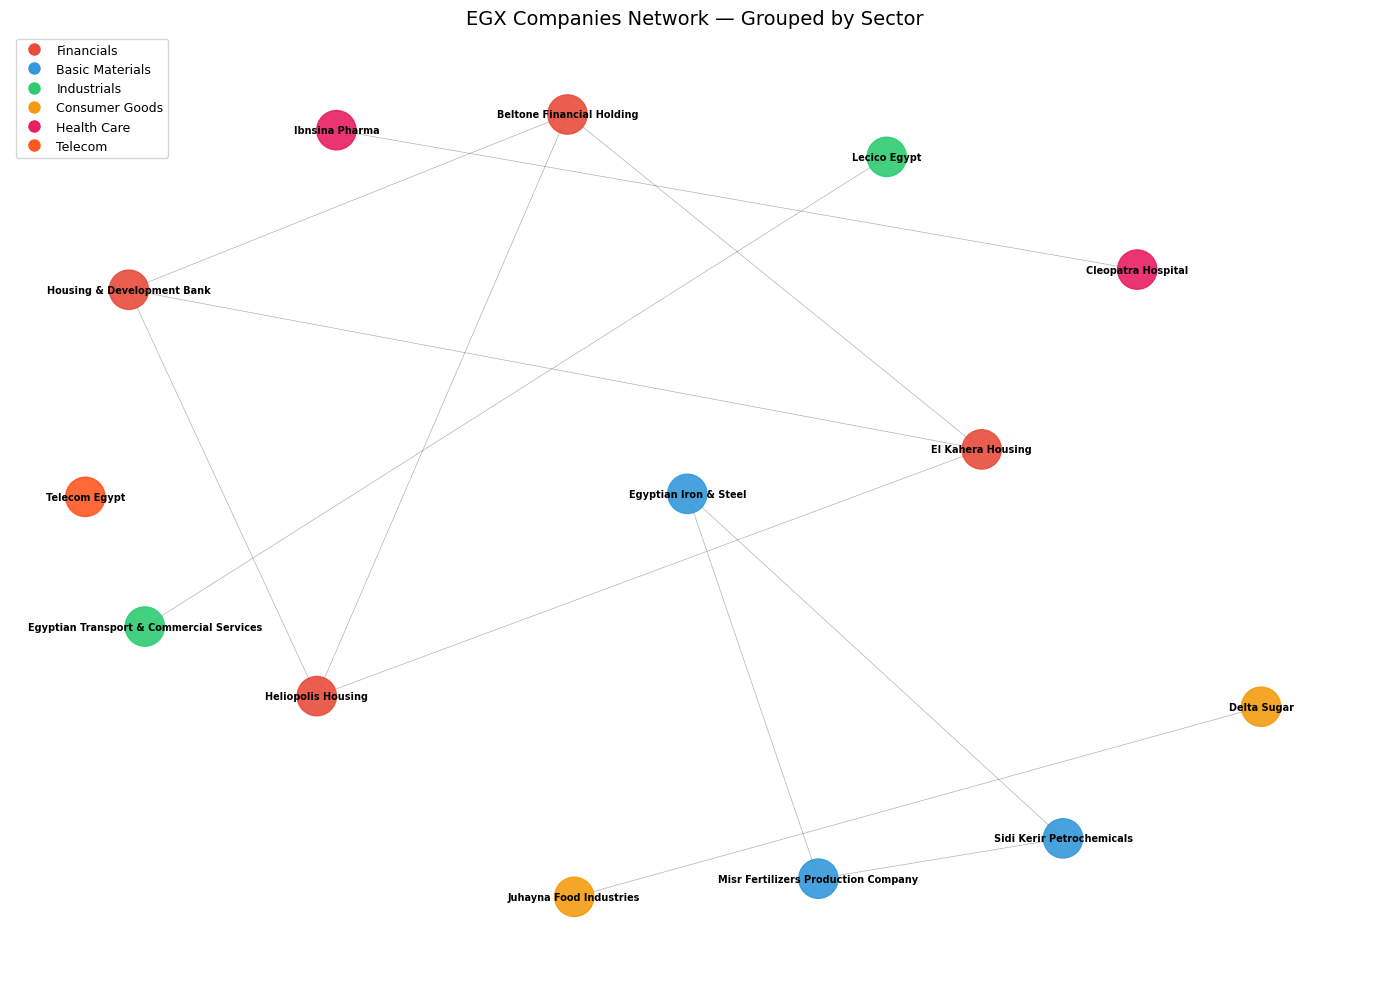

In [15]:
G_sector = nx.Graph()

sectors = df['Sector'].dropna().unique()
for sector in sectors:
    companies = df[df['Sector'] == sector]['Company'].unique()
    for company in companies:
        G_sector.add_node(company, sector=sector)
    for i in range(len(companies)):
        for j in range(i + 1, len(companies)):
            G_sector.add_edge(companies[i], companies[j])

print(f'Nodes: {G_sector.number_of_nodes()}')
print(f'Edges: {G_sector.number_of_edges()}')

node_colors = [sector_colors.get(G_sector.nodes[n].get('sector', ''), '#95a5a6') for n in G_sector.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G_sector, k=2, iterations=50, seed=42)

nx.draw_networkx_nodes(G_sector,  pos, ax=ax, node_color=node_colors, node_size=800, alpha=0.9)
nx.draw_networkx_edges(G_sector,  pos, ax=ax, edge_color='#000000', width=0.5, alpha=0.3)
nx.draw_networkx_labels(G_sector, pos, ax=ax, font_size=7, font_weight='bold')

legend_list = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=s)
    for s, c in sector_colors.items() if s in df['Sector'].dropna().unique()
]
ax.legend(handles=legend_list, loc='upper left', fontsize=9)
ax.set_title('EGX Companies Network — Grouped by Sector', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## 4.2 Sector Portfolio Growth

                 Daily_Return  YTD_Return
Sector                                   
Consumer Goods      -0.000383   -4.469750
Basic Materials     -0.000367    8.291429
Financials          -0.000268   -0.232639
Industrials          0.000130   13.429706
Health Care          0.002758    0.167778
Telecom              0.004235   35.228000


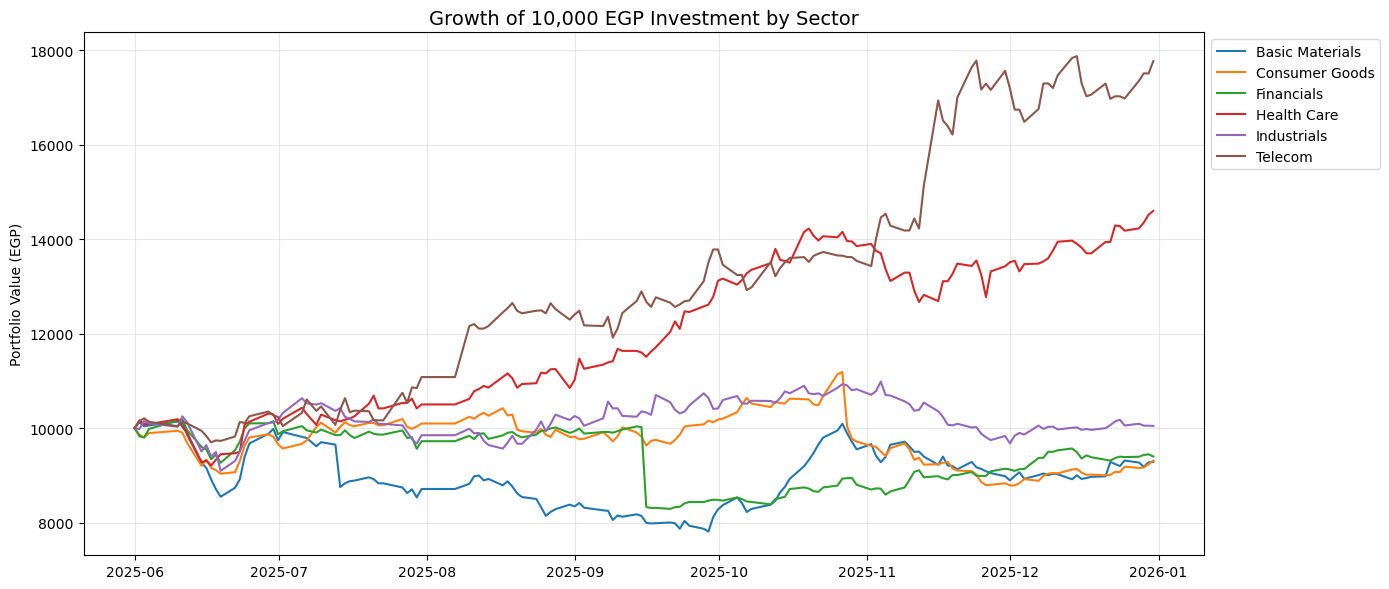

In [16]:
sector_daily = df.groupby('Sector')['Daily_Return'].mean()
sector_ytd   = df2.groupby('Sector')['YTD'].mean()

comparison = pd.DataFrame({'Daily_Return': sector_daily, 'YTD_Return': sector_ytd})
comparison = comparison.dropna().sort_values('Daily_Return')
print(comparison)

sector_stats = df.groupby('Sector').agg(
    Avg_Daily_Return=('Daily_Return', 'mean'),
    Volatility=('Daily_Return', 'std'),
    Total_Volume=('Volume', 'sum')
).reset_index()

sector_mcap = df2.groupby('Sector')['M.Cap'].sum().reset_index()
sector_stats = sector_stats.merge(sector_mcap, on='Sector')

sector_daily_returns = df.groupby(['Date', 'Sector'])['Daily_Return'].mean().reset_index()
sector_pivot = sector_daily_returns.pivot(index='Date', columns='Sector', values='Daily_Return')

initial_investment = 10000
sector_cumulative = initial_investment * (1 + sector_pivot.fillna(0)).cumprod()

plt.figure(figsize=(14, 6))
for sector in sector_cumulative.columns:
    plt.plot(sector_cumulative.index, sector_cumulative[sector], label=sector)
plt.title(f'Growth of {initial_investment:,} EGP Investment by Sector', fontsize=14)
plt.ylabel('Portfolio Value (EGP)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3 Monthly Sector Heatmap

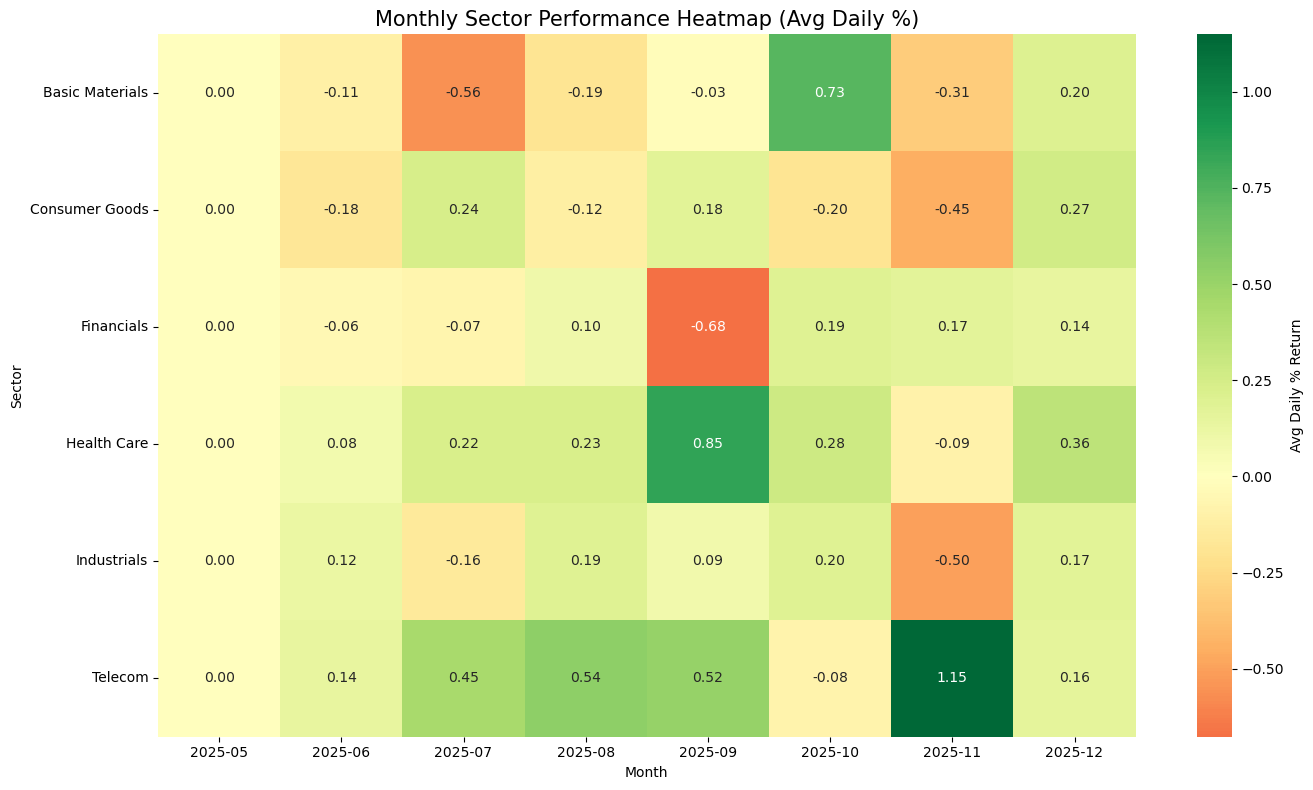

In [17]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sector_returns = (
    df.groupby(['Month', 'Sector'])['Daily_Return']
      .mean()
      .unstack()
      .fillna(0)
)
monthly_sector_returns.index = monthly_sector_returns.index.astype(str)

plt.figure(figsize=(14, 8))
sns.heatmap(
    monthly_sector_returns.T * 100,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    cbar_kws={'label': 'Avg Daily % Return'}
)
plt.title('Monthly Sector Performance Heatmap (Avg Daily %)', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

## 4.4 Correlation Network

Nodes: 32
Edges: 1
=== Top 10 by Degree ===
  El Kahera Housing: 1
  Misr Fertilizers Production Company: 1
  Abu Kir Fertilizers: 0
  Alexandria Container & Cargo Handling: 0
  Alexandria Mineral Oils: 0
  Beltone Financial Holding: 0
  CIB Egypt: 0
  Cairo Poultry (Koki): 0
  Cleopatra Hospital: 0
  Commercial International Bank (CIB): 0

=== Top 10 by Betweenness ===
  Abu Kir Fertilizers: 0.0000
  Alexandria Container & Cargo Handling: 0.0000
  Alexandria Mineral Oils: 0.0000
  Beltone Financial Holding: 0.0000
  CIB Egypt: 0.0000
  Cairo Poultry (Koki): 0.0000
  Cleopatra Hospital: 0.0000
  Commercial International Bank (CIB): 0.0000
  Delta Sugar: 0.0000
  Egyptian Electrical Cables: 0.0000

Most Important: Abu Kir Fertilizers (0.0000)


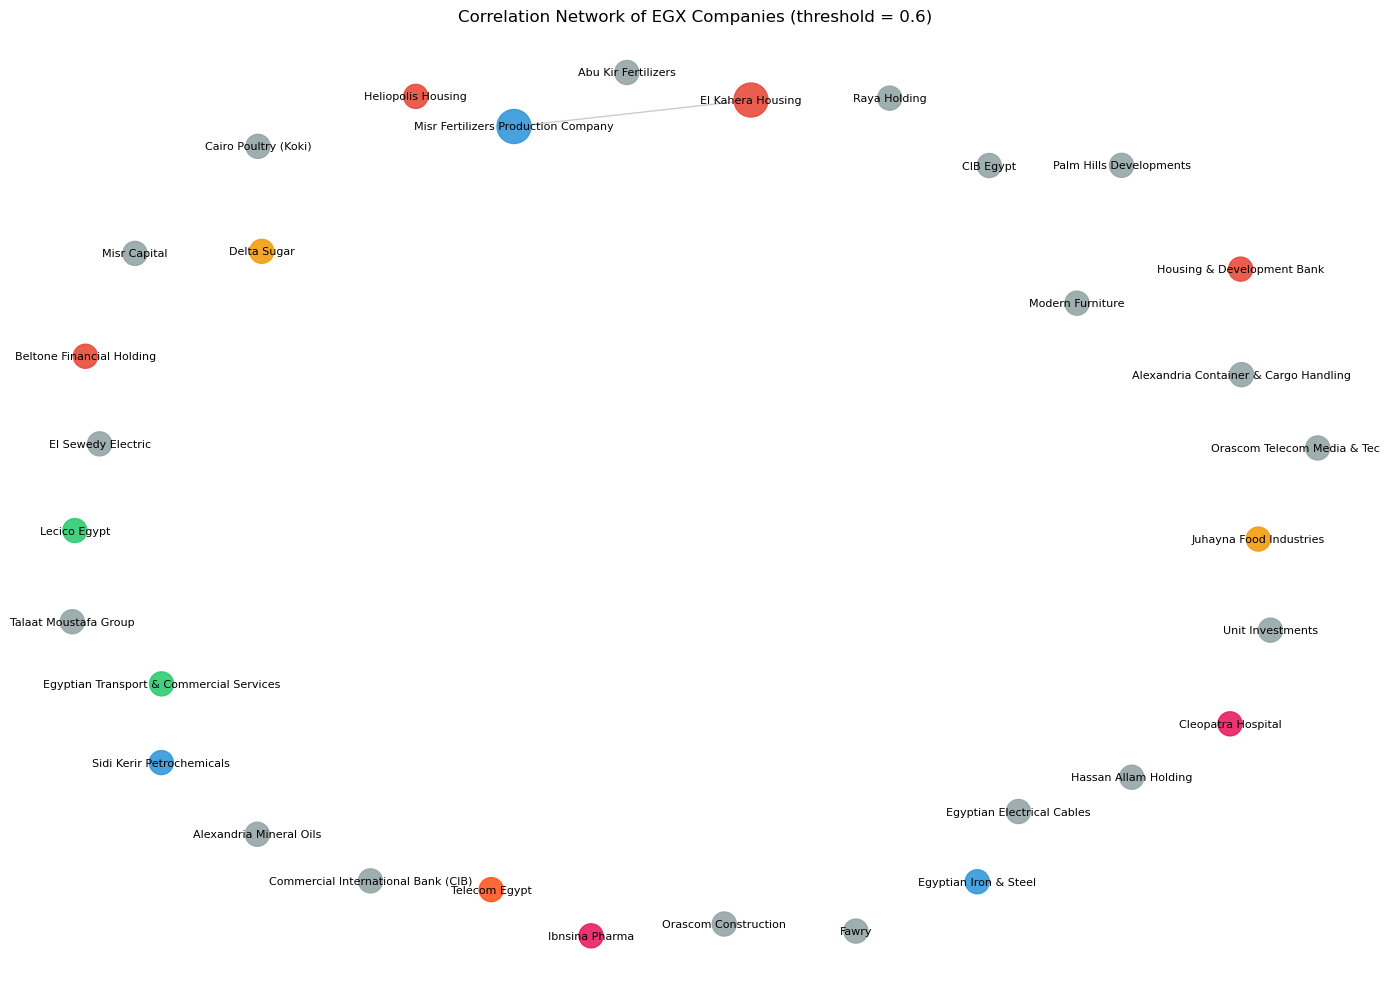

In [18]:
pivot_returns = df.pivot_table(values='Daily_Return', index='Date', columns='Company')
corr = pivot_returns.corr()

threshold = 0.6
G_corr = nx.Graph()

for company in corr.columns:
    G_corr.add_node(company, sector=sector_map.get(company, 'Unknown'))

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if corr.iloc[i, j] >= threshold:
            G_corr.add_edge(corr.columns[i], corr.columns[j], weight=corr.iloc[i, j])

print('Nodes:', G_corr.number_of_nodes())
print('Edges:', G_corr.number_of_edges())

degrees = dict(G_corr.degree())
betweenness = nx.betweenness_centrality(G_corr, normalized=False)

print('=== Top 10 by Degree ===')
for node, d in sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'  {node}: {d}')

print('\n=== Top 10 by Betweenness ===')
for node, c in sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'  {node}: {c:.4f}')

most_important = max(betweenness, key=betweenness.get)
print(f'\nMost Important: {most_important} ({betweenness[most_important]:.4f})')

node_colors = [sector_colors.get(G_corr.nodes[n].get('sector', ''), '#95a5a6') for n in G_corr.nodes()]
node_sizes  = [300 + G_corr.degree[n] * 300 for n in G_corr.nodes()]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_corr, k=1.5, seed=42)
nx.draw_networkx_nodes(G_corr,  pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G_corr,  pos, edge_color='gray', alpha=0.4)
nx.draw_networkx_labels(G_corr, pos, font_size=8)
plt.title(f'Correlation Network of EGX Companies (threshold = {threshold})')
plt.axis('off')
plt.tight_layout()
plt.show()

---
# 2. Volatility & Risk Metrics

## 2.1 Annualised Volatility
Volatility measures the dispersion of daily returns. Annualising scales daily standard deviation to a yearly figure using the square-root-of-time rule:

$$\sigma_{annual} = \sigma_{daily} \times \sqrt{252}$$

where 252 is the conventional number of trading days per year.

In [22]:
TRADING_DAYS = 252
RISK_FREE    = 0.0          # annualised; adjust if a benchmark rate is available

risk = df.groupby('Company')['Daily_Return'].agg(
    Mean_Daily_Return='mean',
    Std_Daily_Return='std'
).dropna()

risk['Ann_Return']     = risk['Mean_Daily_Return'] * TRADING_DAYS
risk['Ann_Volatility'] = risk['Std_Daily_Return']  * np.sqrt(TRADING_DAYS)

risk = risk.reset_index()
risk['Sector'] = risk['Company'].map(sector_map)

print(risk[['Company', 'Ann_Return', 'Ann_Volatility', 'Sector']]
      .sort_values('Ann_Volatility', ascending=False)
      .to_string(index=False))

                                 Company  Ann_Return  Ann_Volatility          Sector
                    Orascom Construction   -1.172688        1.033702             NaN
                      Heliopolis Housing   -1.174127        0.935314      Financials
                            Misr Capital    2.727015        0.712630             NaN
                   Egyptian Iron & Steel   -0.010779        0.559722 Basic Materials
     Misr Fertilizers Production Company   -0.254417        0.440534 Basic Materials
                    Cairo Poultry (Koki)    0.377855        0.432692             NaN
                            Raya Holding    0.505000        0.408257             NaN
                        Modern Furniture   -0.104670        0.407772             NaN
               Beltone Financial Holding    0.260173        0.392941      Financials
                 Juhayna Food Industries   -0.024252        0.383438  Consumer Goods
                      Cleopatra Hospital    0.891512        0.364

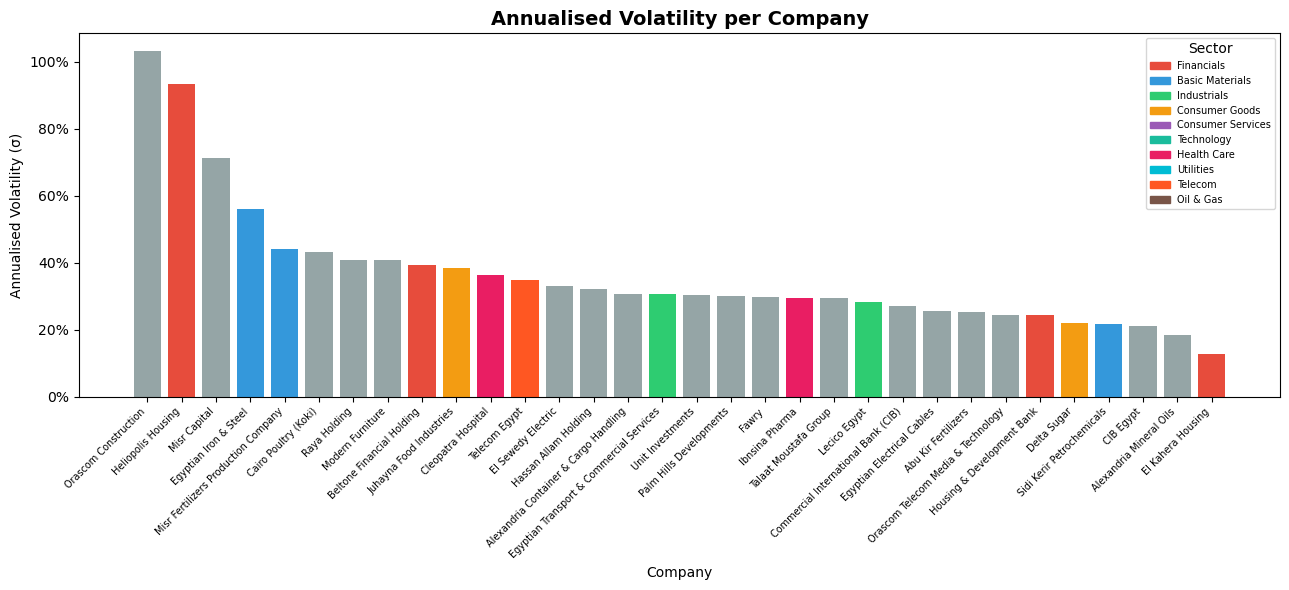

In [23]:
sector_colors = {
    'Financials': '#e74c3c', 'Basic Materials': '#3498db',
    'Industrials': '#2ecc71', 'Consumer Goods': '#f39c12',
    'Consumer Services': '#9b59b6', 'Technology': '#1abc9c',
    'Health Care': '#e91e63', 'Utilities': '#00bcd4',
    'Telecom': '#ff5722', 'Oil & Gas': '#795548'
}

fig, ax = plt.subplots(figsize=(13, 6))
colors = risk['Sector'].map(sector_colors).fillna('#95a5a6')
bars = ax.bar(risk.sort_values('Ann_Volatility', ascending=False)['Company'],
              risk.sort_values('Ann_Volatility', ascending=False)['Ann_Volatility'],
              color=colors.reindex(risk.sort_values('Ann_Volatility', ascending=False).index))
ax.set_title('Annualised Volatility per Company', fontsize=14, fontweight='bold')
ax.set_xlabel('Company')
ax.set_ylabel('Annualised Volatility (σ)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=45, ha='right', fontsize=7)

handles = [plt.Rectangle((0,0),1,1, color=c) for c in sector_colors.values()]
ax.legend(handles, sector_colors.keys(), loc='upper right', fontsize=7, title='Sector')
plt.tight_layout()
plt.show()

## 2.4 Rolling 30-Day Volatility

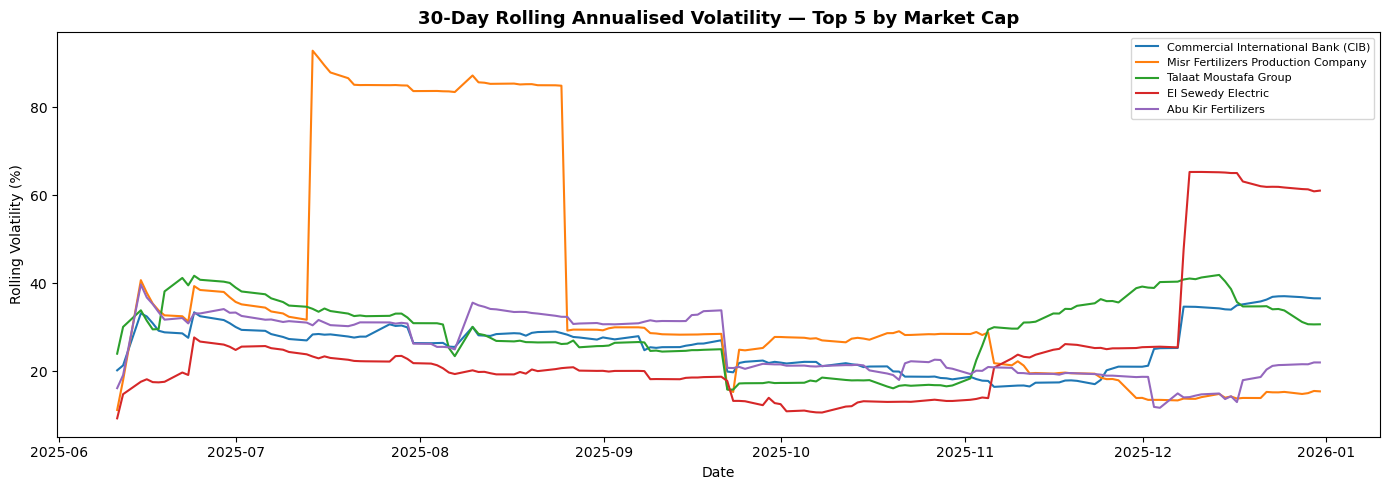

In [24]:
# Show rolling volatility for the top-5 companies by market cap
top5 = (
    df.groupby('Company')['MarketCap'].mean()
      .nlargest(5).index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 5))

for company in top5:
    sub = df[df['Company'] == company].set_index('Date').sort_index()
    rolling_vol = sub['Daily_Return'].rolling(30, min_periods=5).std() * np.sqrt(TRADING_DAYS)
    ax.plot(rolling_vol.index, rolling_vol * 100, label=company)

ax.set_title('30-Day Rolling Annualised Volatility — Top 5 by Market Cap', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Volatility (%)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [26]:
df['Vol_Rolling_Mean'] = df.groupby('Company')['Volume'].transform(
    lambda x: x.rolling(30, min_periods=5).mean()
)
df['Vol_Rolling_Std'] = df.groupby('Company')['Volume'].transform(
    lambda x: x.rolling(30, min_periods=5).std()
)
df['Vol_ZScore'] = (df['Volume'] - df['Vol_Rolling_Mean']) / df['Vol_Rolling_Std'].replace(0, np.nan)
df['Vol_Anomaly'] = df['Vol_ZScore'] > 2

anomalies = df[df['Vol_Anomaly']].copy()
print(f'Total volume anomaly days: {len(anomalies)}')
print(anomalies[['Date', 'Company', 'Sector', 'Volume', 'Vol_ZScore', 'Daily_Return']]
      .sort_values('Vol_ZScore', ascending=False)
      .head(20)
      .to_string(index=False))

Total volume anomaly days: 273
               Date                                  Company         Sector    Volume  Vol_ZScore  Daily_Return
2025-12-28 22:00:00               Housing & Development Bank     Financials   2020285    5.271651      0.019242
2025-09-23 21:00:00               Housing & Development Bank     Financials   2266311    5.237397      0.005775
2025-12-21 22:00:00 Egyptian Transport & Commercial Services    Industrials  22213108    5.180451      0.015038
2025-12-20 22:00:00                       Cleopatra Hospital    Health Care  17655567    5.142313      0.023200
2025-12-30 22:00:00               Egyptian Electrical Cables            NaN  76281306    5.117509      0.091228
2025-11-16 22:00:00                        El Kahera Housing     Financials   1480344    5.062874     -0.018786
2025-11-05 22:00:00                       El Sewedy Electric            NaN   2571412    5.017802      0.054393
2025-10-15 21:00:00               Egyptian Electrical Cables            N

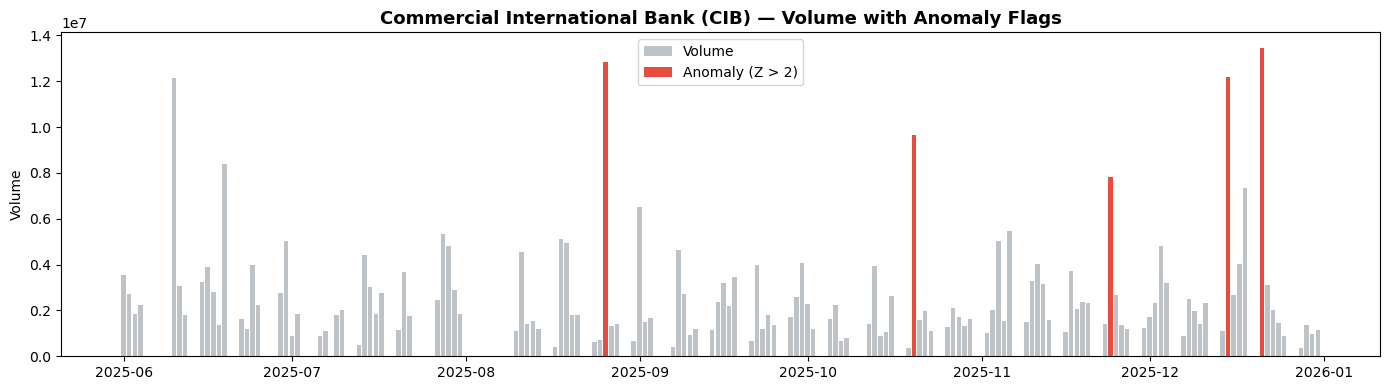

In [28]:

top_company = df.groupby('Company')['MarketCap'].mean().idxmax()
sub_vol = df[df['Company'] == top_company].set_index('Date').sort_index()
anom    = sub_vol[sub_vol['Vol_Anomaly']]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(sub_vol.index, sub_vol['Volume'], color='#bdc3c7', label='Volume')
ax.bar(anom.index, anom['Volume'], color='#e74c3c', label='Anomaly (Z > 2)')
ax.set_title(f'{top_company} — Volume with Anomaly Flags', fontsize=13, fontweight='bold')
ax.set_ylabel('Volume')
ax.legend()
plt.tight_layout()
plt.show()